# **Tridiagonal matrix solver**

---

## **Problem**
Here we'll solve the equation:

$$f^{\prime\prime} = g(x)$$

with $g(x) = sin(x)$, and the domain $x \in [0, 2\pi]$, with boundary conditions $f(0) = f(2\pi) = 0$.  The solution is simply $f(x) = -sin(x)$.

We'll use a grid of $N$ points with $x_0$ on the left boundary and $x_{N-1}$ on the right boundary.

We difference our equation according to the finite differences scheme, namely

$$\frac{f_{i+1} - 2 f_i + f_{i-1}}{\Delta x^2} = g_i$$

We keep the boundary points fixed, so we only need to solve for the $N-2$ interior points.  Near the boundaries, our difference is:
$$f_2 - 2 f_1 = \Delta x^2 g_1$$

and

$$-2f_{N-1} + f_{N-2} = \Delta x^2 g_{N-1}$$.

We can write the system of equations for solving for the $N-2$ interior points as:

\begin{equation}
A = \left (
\begin{array}{ccccccc}
-2 &  1 &    &        &         &           &          \newline
1  & -2 &  1 &        &         &           &          \newline
   &  1 & -2 & 1      &         &           &          \newline
   &         & \ddots & \ddots & \ddots  &           &          \newline
   &         &        & \ddots & \ddots  & \ddots  &          \newline
   &         &        &        & 1       & -2 & 1  \newline
   &         &        &        &         & 1  & -2 \newline
\end{array}
\right )
\end{equation}

\begin{equation}
x = \left (
\begin{array}{c}
f_\mathrm{1} \\\
f_\mathrm{2} \\\
f_\mathrm{3} \\\
\vdots \\\
\vdots \\\
f_\mathrm{N-2} \\\
f_\mathrm{N-1} \\\
\end{array}
\right )
\end{equation}

\begin{equation}
b = \Delta x^2 \left (
\begin{array}{c}
g_\mathrm{1} \\\
g_\mathrm{2} \\\
g_\mathrm{3} \\\
\vdots \\\
\vdots \\\
g_\mathrm{N-2} \\\
g_\mathrm{N-1}\\\
\end{array}
\right )
\end{equation}

Then we just solve $A x = b$

## **Solution**

---



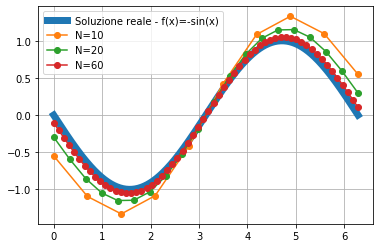

In [74]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 300)
plt.plot(x, -np.sin(x), linewidth=7, label='Soluzione reale - f(x)=-sin(x)')

for N in [10, 20, 60]:
  x = np.linspace(0, 2*np.pi, N)
  h=2*np.pi/(N-1)

  A = np.diag(-2*np.ones(N)) + np.diag(np.ones(N-1), -1) + np.diag(np.ones(N-1), 1)

  b=np.sin(x)*(h*h)

  y=np.linalg.solve(A, b)
  plt.plot(x, y, '-o', label='N='+str(N))
  plt.grid(axis='both')
  plt.legend()
  plt.show

  yr = -np.sin(x)
  err=y-yr
  errinf=np.linalg.norm(err, np.inf)
  err2=np.linalg.norm(err, 2)

**Convergence behaviour**

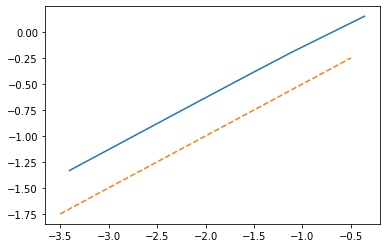

In [86]:
errinfVect=[]
err2Vect=[]
hVect=[]
for N in range(10, 200, 10):
  x = np.linspace(0, 2*np.pi, N)
  h=2*np.pi/(N-1)
  hVect.append(h)
  A = np.diag(-2*np.ones(N)) + np.diag(np.ones(N-1), -1) + np.diag(np.ones(N-1), 1)

  b=np.sin(x)*(h*h)

  y=np.linalg.solve(A, b)

  yr = -np.sin(x)
  err=y-yr
  errinf=np.linalg.norm(err, np.inf)
  err2=np.linalg.norm(err, 2)

  errinfVect.append(errinf)
  err2Vect.append(err2)

plt.plot(np.log(hVect), np.log(err2Vect))
plt.plot([-3.5, -0.5], [0.5*(-3.5), 0.5*(-0.5)], '--')